# Canonical Model 04: Full PEST Calibration and Results

This notebook completes the calibration-facing workflow: establish the canonical
target contract, build a synthetic truth experiment, create a deliberately biased
starting model, generate a reusable PEST++ workspace, optionally run a real
multi-worker optimization, and reopen the calibrated model for review.

> **Why a compact calibration analogue?** The master canonical model remains the
> conceptual reference, but repeated PEST forward runs need a smaller experiment
> that finishes quickly enough to test the entire calibration loop. The compact
> model retains UZF, two lakes, diverted SFR, DRN seepage zones, transient forcing,
> and the canonical observation families.

In [5]:
from pathlib import Path
import json
import shutil
import subprocess
import sys

import pandas as pd
import pyemu
import myflopy as mf
from canonical_notebook_style import notebook_header
from myflopy.modflow.mf6.pest.gold_standard_demo import (
    GoldStandardPestDemoConfig,
    build_and_optionally_run_gold_standard_demo,
)

notebook_header(
    '04',
    'Full PEST Calibration and Results',
    'Build truth and starting models, calibrate with PEST++, then reopen and review every target family.',
)

artifact_root = Path('../artifacts/canonical_pest')
artifact_root.mkdir(parents=True, exist_ok=True)

# Safe default: build and validate the complete PEST workspace without launching
# a potentially long optimization. Change this one switch for a real run.
RUN_PESTPP = True
NOPTMAX = 2
N_WORKERS = 8
KEEP_WORKERS = False
PESTPP_EXE = shutil.which('pestpp-glm') or 'pestpp-glm'

pd.Series({
    'run_pestpp': RUN_PESTPP,
    'noptmax': NOPTMAX,
    'workers': N_WORKERS,
    'pestpp_executable': PESTPP_EXE,
}, name='calibration controls')

run_pestpp                                                            True
noptmax                                                                  2
workers                                                                  8
pestpp_executable    C:\Users\lukem\Python\PATH\modflow_exe\pestpp-glm.EXE
Name: calibration controls, dtype: object

## 1. Anchor the canonical contract

The canonical reference model defines the package and observation vocabulary used
throughout the suite. We build it here without running it again, then confirm the
five target families carried into the calibration experiment.

In [6]:
canonical_reference = mf.build_canonical_model(
    artifact_root / 'canonical_reference',
    config=mf.CanonicalModelConfig.validation(),
)

canonical_target_families = {
    'heads': canonical_reference.targets.heads,
    'lake_stage': canonical_reference.targets.lake_stage,
    'sfr_stage': canonical_reference.targets.sfr_stage,
    'sfr_flow': canonical_reference.targets.sfr_flow,
    'drn_flow': canonical_reference.targets.drn_flow,
}

pd.DataFrame([
    {
        'target_family': name,
        'target_class': type(targets).__name__,
        'configured': targets is not None,
    }
    for name, targets in canonical_target_families.items()
]).set_index('target_family')

VoronoiGrid initializing.
Voronoi grid initialized.
Imported 1 features from ..\artifacts\canonical_pest\canonical_reference\inputs\north_lake.gpkg
Imported 1 features from ..\artifacts\canonical_pest\canonical_reference\inputs\south_lake.gpkg
Generating connections (rectangular mode) for lake 0
getting connectivity properties (iac, ja, cl12, hwva, nja)
Generating connections (rectangular mode) for lake 1


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.
C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.


,target_class,configured
target_family,,
heads,BoundHeadTargets,True
lake_stage,BoundLakeStageTargets,True
sfr_stage,BoundSfrStageTargets,True
sfr_flow,BoundSfrFlowTargets,True
drn_flow,BoundDrnFlowTargets,True


## 2. Build truth, starting model, targets, and PEST workspace

The builder performs the complete setup sequence:

1. Create spatial inputs and a known heterogeneous truth K field.
2. Run the truth model and materialize synthetic observations.
3. Build and run a biased starting model.
4. Register K pilot-point multipliers, drain elevations, and drain conductance multipliers.
5. Register head, lake-stage, SFR-stage, SFR-flow, and DRN-flow observations.
6. Write `forward_run.py`, metadata, templates, instruction files, and `gold_standard.pst`.
7. Optionally launch PEST++ locally with multiple workers.

In [7]:
config = GoldStandardPestDemoConfig(
    artifact_root=artifact_root,
    run_family='canonical_pest_calibration',
    nx=18,
    ny=16,
    cell_size=120.0,
    pp_spacing=360.0,
)

demo = build_and_optionally_run_gold_standard_demo(
    config,
    run_pestpp=RUN_PESTPP,
    noptmax=NOPTMAX,
    n_workers=N_WORKERS,
    keep_workers=KEEP_WORKERS,
    pestpp_exe=PESTPP_EXE,
)

pd.Series({
    'workspace_root': demo.workspace_root,
    'truth_workspace': demo.truth_workspace,
    'starting_model_workspace': demo.model_workspace,
    'pest_template_workspace': demo.pest_workspace,
    'result_workspace': demo.result_workspace,
    'control_file': demo.pest_workspace / demo.control_file,
}, name='workflow artifacts')

VoronoiGrid initializing.
Voronoi grid initialized.
VoronoiGrid initializing.
Voronoi grid initialized.
Imported 1 features from ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\inputs\north_lake.gpkg
Imported 1 features from ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\inputs\south_lake.gpkg
Generating connections (rectangular mode) for lake 0
getting connectivity properties (iac, ja, cl12, hwva, nja)
Generating connections (rectangular mode) for lake 1


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model gold_demo_truth...
    writing model name file...
    writing package disv...
    writing package oc...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package chd...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 16 based on size of stress_period_data
    writing package ghb...
INFORMATION: maxbound in ('', 'ghb', 'dimensions') changed to 16 based on size of stress_period_data
    writing package lak...
    writing package sfr...
    writing package mvr...
    writing package drn...
INFORMATION: maxbound in ('', 'drn', 'dimensions') changed to 104 based on size of stress_period_data
    writing package uzf...
    writing package gwf_obs...
    writing package lak_obs...
    writing package sfr_obs...
    writing package drn_flow_obs...

Saved model object to .model file: ..\artifact

C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

VoronoiGrid initializing.
Voronoi grid initialized.
Imported 1 features from ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\inputs\north_lake.gpkg
Imported 1 features from ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\inputs\south_lake.gpkg
Generating connections (rectangular mode) for lake 0
getting connectivity properties (iac, ja, cl12, hwva, nja)
Generating connections (rectangular mode) for lake 1
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model gold_demo...
    writing model name file...
    writing package disv...
    writing package oc...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package chd...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 16 based on size of stress_period_data
    writing package ghb...
INFORMATION: maxbound in ('', 'ghb', 'dimensions') changed to 16 

...

    writing package lak...
    writing package sfr...
    writing package mvr...
    writing package drn...
INFORMATION: maxbound in ('', 'drn', 'dimensions') changed to 104 based on size of stress_period_data
    writing package uzf...
    writing package gwf_obs...
    writing package lak_obs...
    writing package sfr_obs...
    writing package drn_flow_obs...

Saved model object to .model file: ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\model\gold_demo\gold_demo.model

FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\..\..\mf-env\.venv\Scripts\mf6.exe
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                        VERSION 6.8.0.dev0+cb8a12e.dirty
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Jun 07 2026 15:32:35 with Intel(R) Fortran Intel(R) 64
  Compiler Classic for applications running on Intel(R) 64, Version 2021.12.0
   

C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

noptmax:2, npar_adj:42, nnz_obs:168
Running parallel PEST++ with 8 workers
Template workspace: ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest
Master workspace: ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest_master
master:C:\Users\lukem\Python\PATH\modflow_exe\pestpp-glm.EXE gold_standard.pst /h :4885 in ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest_master
worker:C:\Users\lukem\Python\PATH\modflow_exe\pestpp-glm.EXE gold_standard.pst /h localhost:4885 in ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\workers\worker_0
worker:C:\Users\lukem\Python\PATH\modflow_exe\pestpp-glm.EXE gold_standard.pst /h localhost:4885 in ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\workers\worker_1
worker:C:\Users\lukem\Python\PATH\modflow_exe\pestpp-glm.EXE gold_standard.pst /h localhost:4885 in ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\workers

C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

workspace_root                                     ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259
truth_workspace                              ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\truth
starting_model_workspace                     ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\model
pest_template_workspace                       ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest
result_workspace                       ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest_master
control_file                ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest\gold_standard.pst
Name: workflow artifacts, dtype: object

## 3. Inspect targets and the baseline mismatch

The target objects are independent of PEST. They can be inspected, plotted, and
compared against any compatible model. The starting model is intentionally wrong,
so its residual statistics should leave meaningful work for calibration.

In [8]:
target_summary = pd.DataFrame([
    {
        'target_family': name,
        'target_class': type(targets).__name__,
        'records': len(targets.to_long()),
    }
    for name, targets in demo.targets.items()
]).set_index('target_family')

baseline_stats = pd.read_csv(demo.review_dir / 'baseline_target_stats.csv')
display(target_summary)
display(baseline_stats)

uninformative = baseline_stats.loc[baseline_stats['rmse'].fillna(0.0) <= 1.0e-10, 'dataset'].tolist()
if uninformative:
    print(
        'Identifiability warning: these target families currently have zero baseline residual '
        f'and cannot inform calibration without adjusting the experiment: {uninformative}'
    )

,target_class,records
target_family,,
heads,HeadTargets,102
lake_stage,LakeStageTargets,12
sfr_stage,SfrStageTargets,18
sfr_flow,SfrFlowTargets,18
drn_flow,DrnFlowTargets,18


,n,mean_error,mae,rmse,dataset
0,102,0.055408,0.850247,0.967055,heads
1,12,0.904686,0.904686,0.926314,lake_stage
2,18,-0.000002,0.000002,0.000002,sfr_stage
3,18,-0.043254,0.043254,0.054284,sfr_flow
4,18,0.000000,0.000000,0.000000,drn_flow


Identifiability warning: these target families currently have zero baseline residual and cannot inform calibration without adjusting the experiment: ['drn_flow']


## 4. Inspect the generated PEST control problem

This reads the actual `.pst` file written by the workflow. Parameter groups,
bounds, transformations, observation groups, and weights shown here are exactly
what PEST++ will use.

In [9]:
pst_path = demo.pest_workspace / demo.control_file
pst = pyemu.Pst(str(pst_path))

control_summary = pd.Series({
    'noptmax': pst.control_data.noptmax,
    'adjustable_parameters': pst.npar_adj,
    'nonzero_weight_observations': pst.nnz_obs,
    'parameter_groups': pst.parameter_data['pargp'].nunique(),
    'observation_groups': pst.observation_data['obgnme'].nunique(),
}, name='PEST control problem')

display(control_summary)
display(
    pst.parameter_data[
        ['parnme', 'pargp', 'partrans', 'parval1', 'parlbnd', 'parubnd']
    ].groupby('pargp').agg(
        parameters=('parnme', 'count'),
        transform=('partrans', 'first'),
        lower_bound=('parlbnd', 'min'),
        upper_bound=('parubnd', 'max'),
    )
)
display(
    pst.observation_data.groupby('obgnme').agg(
        observations=('obsnme', 'count'),
        nonzero_weight=('weight', lambda values: int((values > 0).sum())),
        mean_weight=('weight', 'mean'),
    )
)

noptmax                          2
adjustable_parameters           42
nonzero_weight_observations    168
parameter_groups                 3
observation_groups              28
Name: PEST control problem, dtype: int64

,parameters,transform,lower_bound,upper_bound
pargp,,,,
drn_cond,3,log,0.05,12.0
drn_elev,3,none,-8.00,8.0
hk_pp,36,log,0.05,15.0


,observations,nonzero_weight,mean_weight
obgnme,,,
oname:drn_flow_otype:lst_usecol:central_seepage,6,6,1.0
oname:drn_flow_otype:lst_usecol:north_seepage,6,6,1.0
oname:drn_flow_otype:lst_usecol:south_seepage,6,6,1.0
oname:hds_otype:lst_usecol:gw_01,6,6,1.0
oname:hds_otype:lst_usecol:gw_02,6,6,1.0
oname:hds_otype:lst_usecol:gw_03,6,6,1.0
oname:hds_otype:lst_usecol:gw_04,6,6,1.0
oname:hds_otype:lst_usecol:gw_05,6,6,1.0
oname:hds_otype:lst_usecol:gw_06,6,6,1.0


## 5. Validate the generated forward model

Every PEST iteration calls `forward_run.py`. Running it once directly is the most
important setup check: it must apply parameter files, run MODFLOW successfully,
and regenerate all simulated-observation outputs before a long optimization is
started.

In [10]:
forward_run = subprocess.run(
    [sys.executable, 'forward_run.py'],
    cwd=demo.pest_workspace,
    capture_output=True,
    text=True,
)
assert forward_run.returncode == 0, forward_run.stdout + '\n' + forward_run.stderr

expected_outputs = {
    'heads': 'hds_simulated_heads.csv',
    'lake_stage': 'lak_stage_simulated_lake_stage.csv',
    'sfr_stage': 'sfr_stage_simulated_sfr_stage.csv',
    'sfr_flow': 'sfr_flow_simulated_sfr_flow.csv',
    'drn_flow': 'drn_flow_simulated_drn_flow.csv',
}

pd.DataFrame([
    {
        'target_family': name,
        'output_file': filename,
        'exists': (demo.pest_workspace / filename).exists(),
        'rows': len(pd.read_csv(demo.pest_workspace / filename)),
    }
    for name, filename in expected_outputs.items()
]).set_index('target_family')

,output_file,exists,rows
target_family,,,
heads,hds_simulated_heads.csv,True,6
lake_stage,lak_stage_simulated_lake_stage.csv,True,6
sfr_stage,sfr_stage_simulated_sfr_stage.csv,True,6
sfr_flow,sfr_flow_simulated_sfr_flow.csv,True,6
drn_flow,drn_flow_simulated_drn_flow.csv,True,6


## 6. Launch a real calibration

The build cell already launches PEST++ when `RUN_PESTPP = True`. For a serious
local run, use `NOPTMAX = 10` or more and `N_WORKERS = 8` or more. PEST++ creates
a `pest_master` result workspace and optional worker directories.

For a long run outside Jupyter, the equivalent command-line workflow is:

```powershell
python ..\gold_standard_pest_demo.py --run-pestpp --noptmax 10 --n-workers 8
```

Keeping the switch near the top prevents an accidental multi-hour solve while
still making the notebook fully executable from beginning to end.

In [11]:
run_info = json.loads(demo.run_info_path.read_text())
pd.Series({
    'optimization_requested': run_info['run_pestpp'],
    'noptmax': run_info['noptmax'],
    'workers': run_info['n_workers'],
    'parameter_families': ', '.join(run_info['implemented_parameter_families']),
    'target_families': ', '.join(run_info['implemented_target_families']),
}, name='requested PEST++ run')

optimization_requested                                                True
noptmax                                                                  2
workers                                                                  8
parameter_families                       k_pilotpoints, drn_elev, drn_cond
target_families           heads, lake_stage, sfr_stage, sfr_flow, drn_flow
Name: requested PEST++ run, dtype: object

## 7. Discover and reopen completed results

`mf.open_pest_run(...)` accepts either the artifact root, the template `pest`
workspace, or a completed `pest_master` workspace. It discovers saved metadata,
loads every target family, reapplies final `.par` values, and returns baseline
and calibrated model objects using the normal `myflopy` model API.

In [12]:
completed_workspace = demo.result_workspace
if completed_workspace is None:
    candidates = [demo.workspace_root / 'pest_master', demo.pest_workspace]
    completed_workspace = next(
        (path for path in candidates if path.exists() and any(path.glob('*.par'))),
        None,
    )

if completed_workspace is None:
    print(
        'No completed .par file exists yet. Set RUN_PESTPP=True and rerun, '
        'or point completed_workspace at a finished artifact root.'
    )
    pest_run = None
else:
    pest_run = mf.open_pest_run(completed_workspace)
    display(pest_run.summary())

,root,baseline_workspace,pest_workspace,pst,par,rec,metadata,materialization,n_saved_head_target_sets,has_final_parameters
0,..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest_master,..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\model\gold_demo,..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest_master,gold_standard.pst,gold_standard.par,gold_standard.rec,myflopy_pest_metadata.json,myflopy_calibrated_materialization.json,1,True


## 8. Reconstruct models and compare every observation family

The final parameter file is not merely summarized: it is applied to reconstruct
the calibrated model object. The same canonical target objects then compare
truth observations against both baseline and calibrated simulations.

In [13]:
if pest_run is not None:
    review = pest_run.review()
    baseline_model = review.baseline_model
    calibrated_model = review.calibrated_model

    reopened_targets = {
        'heads': pest_run.load_head_targets(),
        'lake_stage': pest_run.load_lake_stage_targets(),
        'sfr_stage': pest_run.load_sfr_stage_targets(),
        'sfr_flow': pest_run.load_sfr_flow_targets(),
        'drn_flow': pest_run.load_drn_flow_targets(),
    }

    all_target_stats = pd.concat(
        [
            targets.stats(baseline_model).assign(dataset=name, model='baseline')
            for name, targets in reopened_targets.items()
        ] + [
            targets.stats(calibrated_model).assign(dataset=name, model='calibrated')
            for name, targets in reopened_targets.items()
        ],
        ignore_index=True,
    )
    display(all_target_stats)
else:
    print('Completed-run comparison will become available after PEST++ writes a final .par file.')

[LoadedMf6Run] Loading full MF6 simulation from: ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\pest_master
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package disv...
    loading package oc...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package ghb...
    loading package lak...
    loading package sfr...
    loading package mvr...
    loading package drn...
    loading package uzf...
    loading package obs...
  loading solution package gold_demo...
[LoadedMf6Run] Locating GWF model 'gold_demo'
[LoadedMf6Run] Loading MF6 packages for core access: DISV, OC
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package disv...
    loading package oc...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    skipping package 

C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

,n,mean_error,mae,rmse,dataset,model
0,102,5.540763e-02,8.502474e-01,9.670551e-01,heads,baseline
1,12,9.046855e-01,9.046855e-01,9.263140e-01,lake_stage,baseline
2,18,-1.543145e-06,1.543145e-06,1.940225e-06,sfr_stage,baseline
3,18,-4.325427e-02,4.325427e-02,5.428362e-02,sfr_flow,baseline
4,18,0.000000e+00,0.000000e+00,0.000000e+00,drn_flow,baseline
5,102,3.663487e-02,3.517339e-01,4.360756e-01,heads,calibrated
6,12,5.042855e-01,5.042855e-01,5.196921e-01,lake_stage,calibrated
7,18,-5.139191e-07,5.139191e-07,6.687612e-07,sfr_stage,calibrated
8,18,-1.434138e-02,1.434138e-02,1.867250e-02,sfr_flow,calibrated
9,18,0.000000e+00,0.000000e+00,0.000000e+00,drn_flow,calibrated


## 9. Plot calibration behavior and export a review bundle

Completed runs use the shared `CalibrationPlot` style for observed-versus-simulated,
residual-by-period, and time-series diagnostics. Spatial review includes final K
and the K multiplier ratio. `export_review()` writes portable tables, GeoPackages,
PNG maps, and standalone Plotly HTML diagnostics.

export_root                       ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\review\complete_review
figures_dir                 ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\review\complete_review\fi...
residual_compare_csv        ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\review\complete_review\re...
residual_stats_csv          ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\review\complete_review\re...
k_review_gpkg               ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\review\complete_review\k_...
obs_vs_sim_html             ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\review\complete_review\fi...
residuals_by_period_html    ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\review\complete_review\fi...
k_final_png                 ..\artifacts\canonical_pest\canonical_pest_calibration_20260611_163259\revie

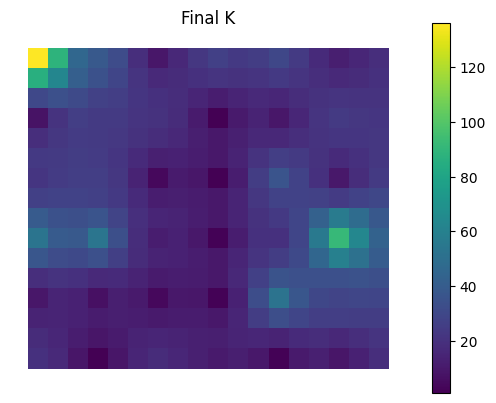

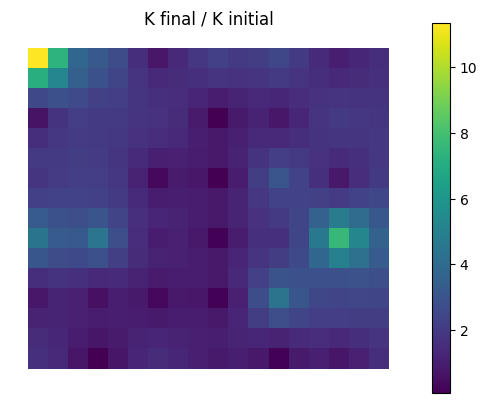

In [14]:
if pest_run is not None:
    display(pest_run.plot_obs_vs_sim())
    display(pest_run.plot_residuals_by_period())
    display(pest_run.plot_well_timeseries('GW_08'))

    ax_k = pest_run.plot_k()
    ax_ratio = pest_run.plot_k_ratio()

    review_manifest = pest_run.export_review(
        demo.review_dir / 'complete_review',
        timeseries_names=['GW_01', 'GW_08', 'GW_14'],
    )
    display(pd.Series(review_manifest, name='exported review'))
else:
    print('Plots and exported calibrated review are intentionally deferred until a final .par file exists.')

## Interpretation checklist

- Confirm the baseline mismatch is meaningful before trusting optimization results.
- Check that head, lake, SFR, and DRN target families improve together rather than allowing one group to dominate.
- Inspect `K_final / K_initial`; spatial changes should be interpretable and supported by observations.
- Review drain elevation offsets and conductance multipliers for plausibility.
- Compare lake and stream behavior to ensure calibration did not improve heads by damaging surface-water physics.
- Treat a lower objective function as evidence, not the entire deliverable.